Dataset Shape: (7043, 50)

========== 3.1 Missing Values Summary ==========
                Missing Values  Missing %
Churn Reason              5174      73.46
Churn Category            5174      73.46
Offer                     3877      55.05
Internet Type             1526      21.67

========== 3.2 Class Imbalance ==========
             Count  Percentage (%)
Churn Label                       
No            5174           73.46
Yes           1869           26.54


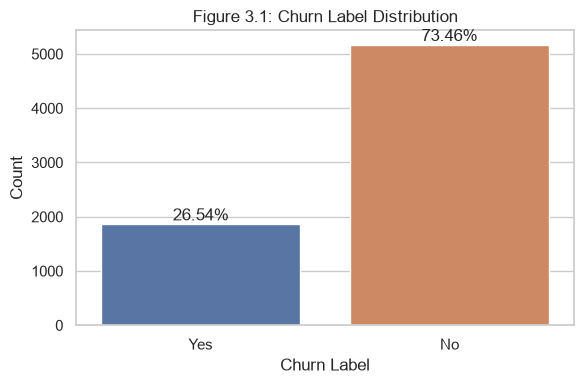


========== 3.3 Correlation and Multicollinearity ==========

Correlation Matrix:
                  Tenure in Months  Monthly Charge  Total Charges  \
Tenure in Months             1.000           0.248          0.826   
Monthly Charge               0.248           1.000          0.651   
Total Charges                0.826           0.651          1.000   
Total Revenue                0.853           0.589          0.972   

                  Total Revenue  
Tenure in Months          0.853  
Monthly Charge            0.589  
Total Charges             0.972  
Total Revenue             1.000  


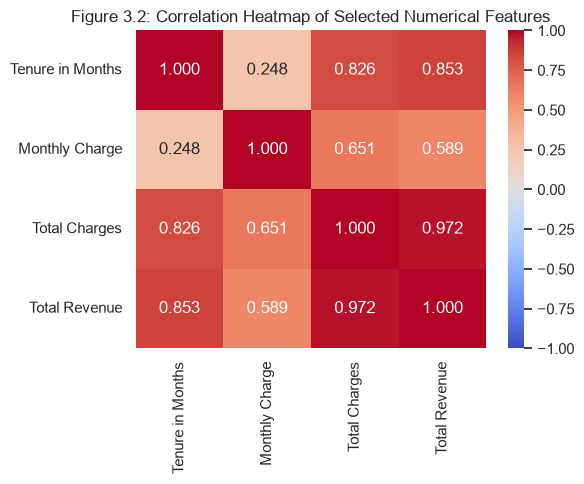


VIF Multicollinearity Analysis:
            Feature  VIF Score
0  Tenure in Months       6.40
1    Monthly Charge       3.22
2     Total Charges      24.40
3     Total Revenue      21.31

========== 3.4 Skewness Summary ==========
                             Skewness
Total Refunds                    4.33
Total Extra Data Charges         4.09
Total Long Distance Charges      1.24
Avg Monthly GB Download          1.22
Total Revenue                    0.92


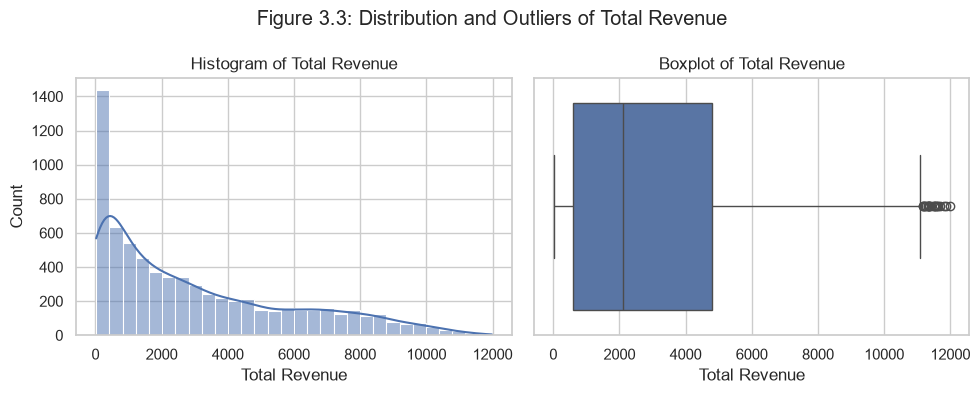


========== 3.5 Duplicate Records ==========
Total duplicate rows found: 0

========== 3.6 Data Consistency Checks ==========
No leading/trailing whitespace inconsistencies detected.

Negative-value checks:
Age: 0 negative values
Tenure in Months: 0 negative values
Monthly Charge: 0 negative values
Total Charges: 0 negative values
Total Refunds: 0 negative values
Total Extra Data Charges: 0 negative values
Total Long Distance Charges: 0 negative values
Total Revenue: 0 negative values


C:\Users\jonnn\AppData\Local\Temp\ipykernel_24696\1006066435.py:235: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant


# ==========================================
# Load Dataset
# ==========================================
df = pd.read_csv('telco.csv')

sns.set_theme(style="whitegrid")

print(f"Dataset Shape: {df.shape}")
print("=" * 60)


# ==========================================
# 3.1 Missing Values and Structural Missingness
# ==========================================
print("\n========== 3.1 Missing Values Summary ==========")

missing_df = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Missing %': (
        df.isnull().sum() / len(df) * 100
    ).round(2)
})

missing_df = missing_df[
    missing_df['Missing Values'] > 0
].sort_values(
    by='Missing %',
    ascending=False
)

print(missing_df)


# ==========================================
# 3.2 Class Imbalance
# ==========================================
print("\n========== 3.2 Class Imbalance ==========")

class_counts = df['Churn Label'].value_counts()
class_pct = (
    df['Churn Label'].value_counts(normalize=True) * 100
).round(2)

class_summary = pd.DataFrame({
    'Count': class_counts,
    'Percentage (%)': class_pct
})

print(class_summary)

plt.figure(figsize=(6, 4))

ax = sns.countplot(
    data=df,
    x='Churn Label',
    hue='Churn Label',
    legend=False
)

plt.title('Figure 3.1: Churn Label Distribution')
plt.xlabel('Churn Label')
plt.ylabel('Count')

total = len(df)

for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.2f}%'

    ax.annotate(
        percentage,
        (
            p.get_x() + p.get_width() / 2,
            p.get_height()
        ),
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()


# ==========================================
# 3.3 Correlation and Multicollinearity
# ==========================================
print("\n========== 3.3 Correlation and Multicollinearity ==========")

selected_num_cols = [
    'Tenure in Months',
    'Monthly Charge',
    'Total Charges',
    'Total Revenue'
]

numeric_data = df[selected_num_cols].dropna()


# ----- Correlation Heatmap -----
correlation_matrix = numeric_data.corr()

print("\nCorrelation Matrix:")
print(correlation_matrix.round(3))

plt.figure(figsize=(6, 5))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1
)

plt.title(
    'Figure 3.2: Correlation Heatmap of Selected Numerical Features'
)

plt.tight_layout()
plt.show()


# ----- VIF Analysis -----
# Add intercept for standard VIF calculation
vif_input = add_constant(numeric_data)

vif_df = pd.DataFrame({
    'Feature': vif_input.columns,
    'VIF Score': [
        variance_inflation_factor(
            vif_input.values,
            i
        )
        for i in range(vif_input.shape[1])
    ]
})

# Do not report the intercept
vif_df = vif_df[
    vif_df['Feature'] != 'const'
].reset_index(drop=True)

vif_df['VIF Score'] = vif_df[
    'VIF Score'
].round(2)

print("\nVIF Multicollinearity Analysis:")
print(vif_df)


# ==========================================
# 3.4 Skewness and Potential Outliers
# ==========================================
print("\n========== 3.4 Skewness Summary ==========")

skew_cols = [
    'Total Refunds',
    'Total Extra Data Charges',
    'Total Long Distance Charges',
    'Avg Monthly GB Download',
    'Total Revenue'
]

skew_df = pd.DataFrame({
    'Skewness': df[skew_cols].skew().round(2)
}).sort_values(
    by='Skewness',
    ascending=False
)

print(skew_df)


# ----- Distribution and Boxplot -----
fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 4)
)

sns.histplot(
    df['Total Revenue'].dropna(),
    bins=30,
    kde=True,
    ax=axes[0]
)

axes[0].set_title(
    'Histogram of Total Revenue'
)

sns.boxplot(
    x=df['Total Revenue'].dropna(),
    ax=axes[1]
)

axes[1].set_title(
    'Boxplot of Total Revenue'
)

plt.suptitle(
    'Figure 3.3: Distribution and Outliers of Total Revenue'
)

plt.tight_layout()
plt.show()


# ==========================================
# 3.5 Duplicate Records
# ==========================================
print("\n========== 3.5 Duplicate Records ==========")

duplicate_count = df.duplicated().sum()

print(
    f"Total duplicate rows found: "
    f"{duplicate_count}"
)


# ==========================================
# 3.6 Basic Data Consistency Checks
# ==========================================
print("\n========== 3.6 Data Consistency Checks ==========")

categorical_cols = df.select_dtypes(
    include=['object']
).columns

whitespace_issues = {}

for col in categorical_cols:

    non_null = df[col].dropna().astype(str)

    issue_count = (
        non_null != non_null.str.strip()
    ).sum()

    if issue_count > 0:
        whitespace_issues[col] = issue_count


if whitespace_issues:
    print("Leading/trailing whitespace issues:")
    print(whitespace_issues)
else:
    print(
        "No leading/trailing whitespace "
        "inconsistencies detected."
    )


# Check selected variables that should not normally be negative
non_negative_cols = [
    'Age',
    'Tenure in Months',
    'Monthly Charge',
    'Total Charges',
    'Total Refunds',
    'Total Extra Data Charges',
    'Total Long Distance Charges',
    'Total Revenue'
]

print("\nNegative-value checks:")

for col in non_negative_cols:

    if col in df.columns:

        negative_count = (
            df[col].dropna() < 0
        ).sum()

        print(
            f"{col}: "
            f"{negative_count} negative values"
        )